- Per-station SARIMAX(p,0,q) on log1p(flow) with Fourier (K=3) + rainfall exog; d=0 forced (series stationary)
- h=1: Kalman-filtered one-step-ahead; h>1: rolling re-anchored every h/2 days
- Outperforms Ridge at all horizons but requires 146 separate models and cannot generalise to unseen stations

In [1]:
import pandas as pd
import numpy as np

results = pd.read_csv('results/sarimax_multihorizon_results.csv')
print(f'Stations: {results["station_id"].nunique()}')
print(f'Shape: {results.shape}')
print()
print('===== Lead-time summary =====')
for h in ['t+1','t+3','t+7','t+10','t+14']:
    sub = results[results['horizon']==h]
    n = sub['test_nse'].dropna()
    k = sub['test_kge'].dropna()
    print(f'  {h}: median log-NSE = {n.median():.3f}, KGE = {k.median():.3f} (n={len(n)})')


Stations: 143
Shape: (667, 6)

===== Lead-time summary =====
  t+1: median log-NSE = 0.796, KGE = 0.865 (n=143)
  t+3: median log-NSE = 0.602, KGE = 0.736 (n=131)
  t+7: median log-NSE = 0.434, KGE = 0.609 (n=131)
  t+10: median log-NSE = 0.345, KGE = 0.545 (n=131)
  t+14: median log-NSE = 0.310, KGE = 0.520 (n=131)


In [2]:
print('Order distribution across all station-horizons:')
print(results['order'].value_counts().to_string())
print()
print('Per-horizon breakdown:')
for h in ['t+1','t+3','t+7','t+10','t+14']:
    sub = results[results['horizon']==h]
    top = sub['order'].value_counts().index[0] if len(sub) > 0 else 'N/A'
    print(f'  {h}: most common order = {top}')


Order distribution across all station-horizons:
order
(2, 0, 1)    359
(3, 0, 0)    135
(1, 0, 1)     61
(1, 0, 0)     57
(2, 0, 0)     55

Per-horizon breakdown:
  t+1: most common order = (2, 0, 1)
  t+3: most common order = (2, 0, 1)
  t+7: most common order = (2, 0, 1)
  t+10: most common order = (2, 0, 1)
  t+14: most common order = (2, 0, 1)


| Horizon | Persistence | SARIMAX (per-station) | Ridge (global pooled) | LightGBM (global pooled) |
|---------|------------|----------------------|----------------------|-------------------------|
| t+1     | 0.770      | **0.796**            | 0.749                | 0.894                   |
| t+3     | ~0.45      | **0.602**            | ~0.55                | —                       |
| t+7     | 0.170      | **0.434**            | 0.381                | 0.459                   |
| t+14    | —          | **0.310**            | 0.312                | 0.374                   |

- SARIMAX outperforms Ridge at all horizons, but requires 146 separate models and cannot generalise to unseen stations

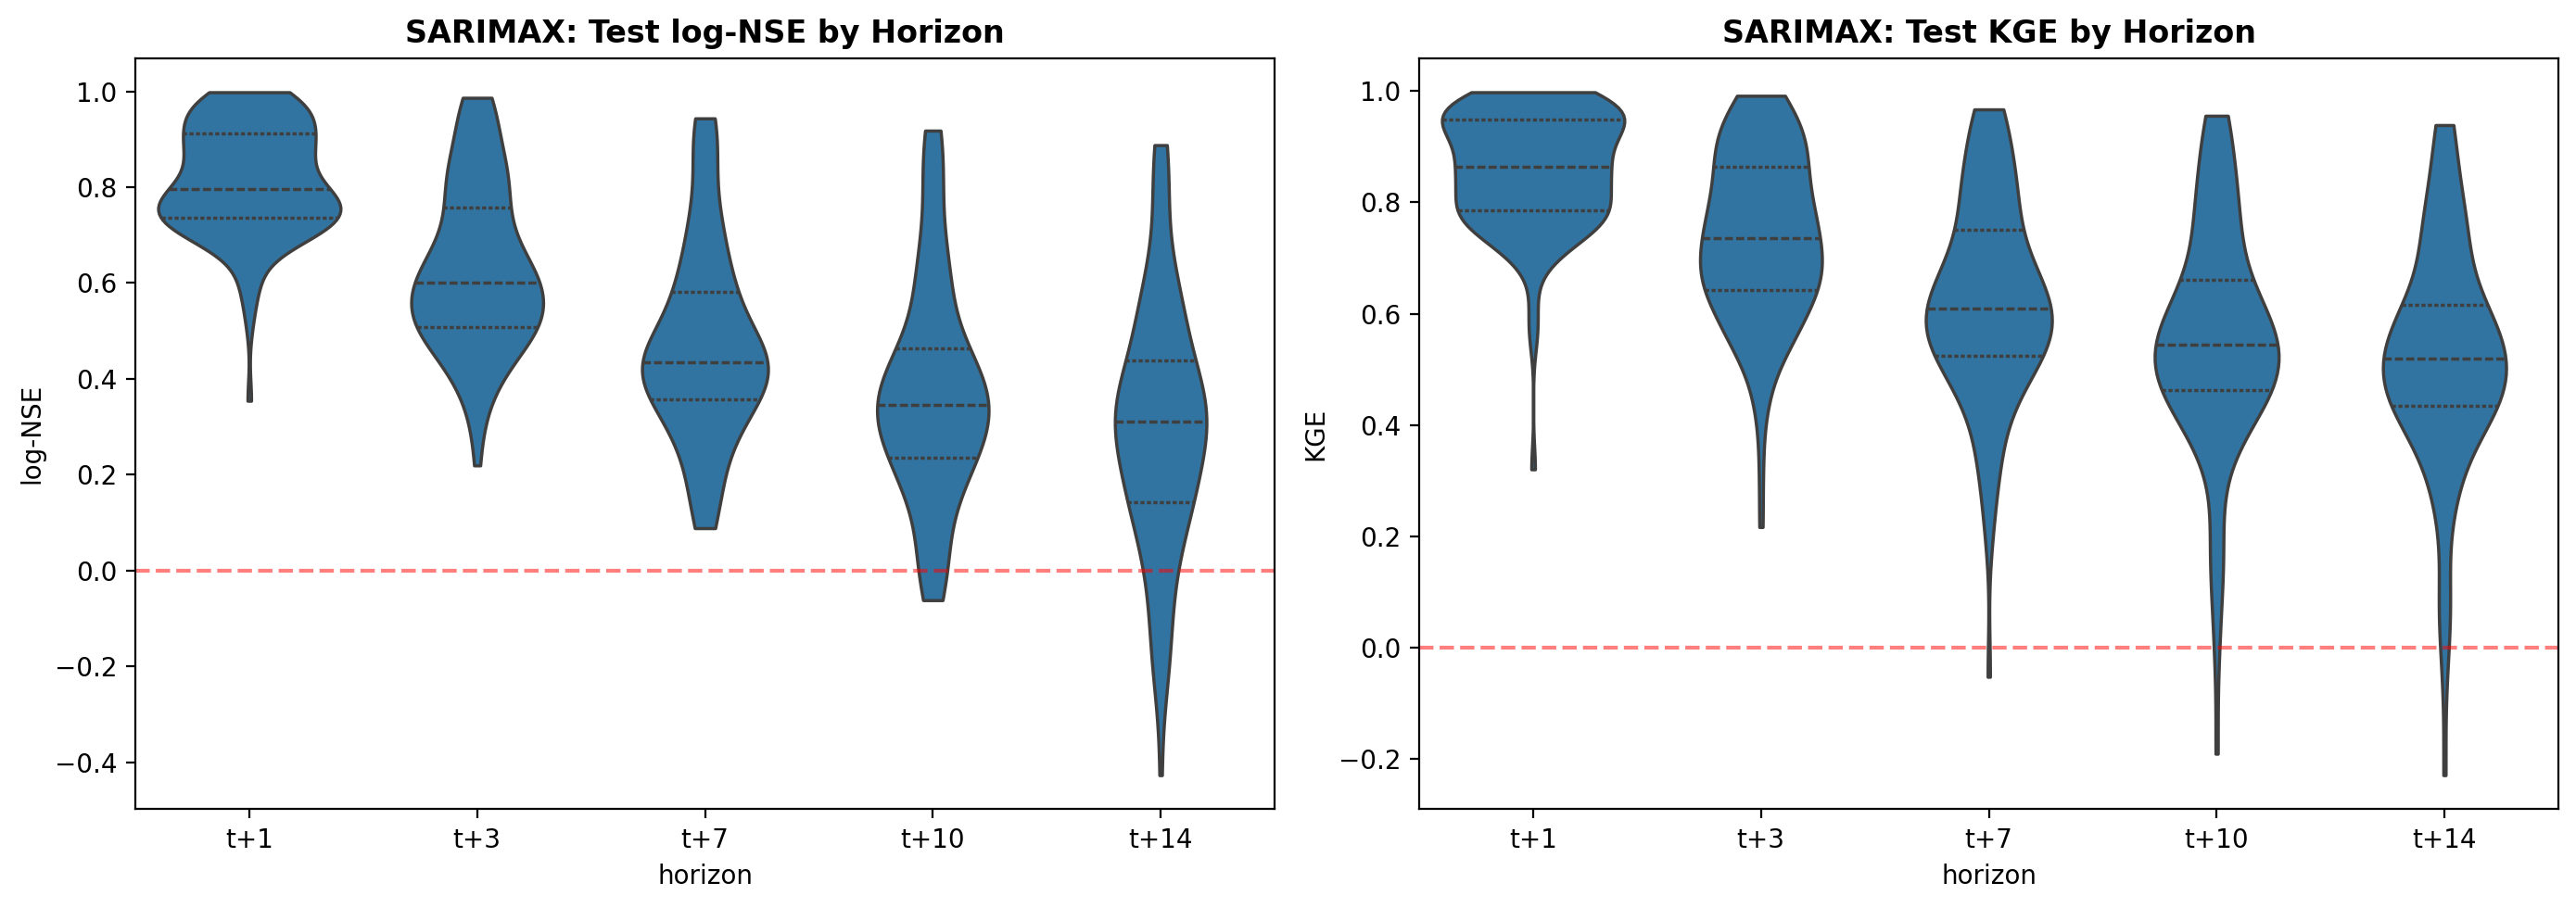

In [3]:
from IPython.display import Image
Image('results/sarimax_multihorizon_violin.png')